In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation

In [10]:
def get_results_imgs(simulation, iterations=50, population_colors=None, save_dir=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    type1 = 'giving'
    type2 = 'attacking'
    type3 = 'random'

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0))
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0))
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0))

    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'Type 1 : {type1}'),
        Patch(facecolor='blue', edgecolor='b', label=f'Type 2 : {type2}'),
        Patch(facecolor='green', edgecolor='g', label=f'Type 3 : {type3}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    #plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final population distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'final_population_distribution.pdf'), bbox_inches='tight')

    plt.show()
    # get the final population sizes
    print('Final population sizes:')
    print(f'Population 1: {type1} - {pop1_size[-1]}')
    print(f'Population 2: {type2} - {pop2_size[-1]}')
    print(f'Population 3: {type3} - {pop3_size[-1]}')

    #
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'Population 1 : {type1}', color='red')
    plt.plot(np.arange(iterations), pop2_size, label=f'Population 2 : {type2}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'Population 3 : {type3}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'population_size_over_time.pdf'), bbox_inches='tight')
    plt.show()

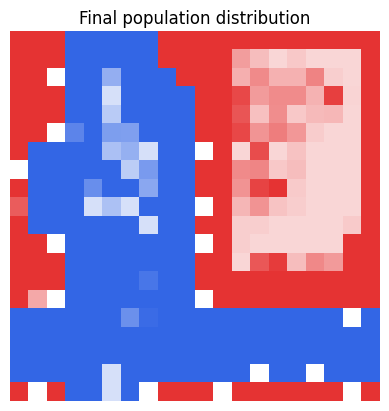

Final population sizes:
Population 1: giving - 13701619.0
Population 2: attacking - 13590051.0
Population 3: random - 0.002551282988861203


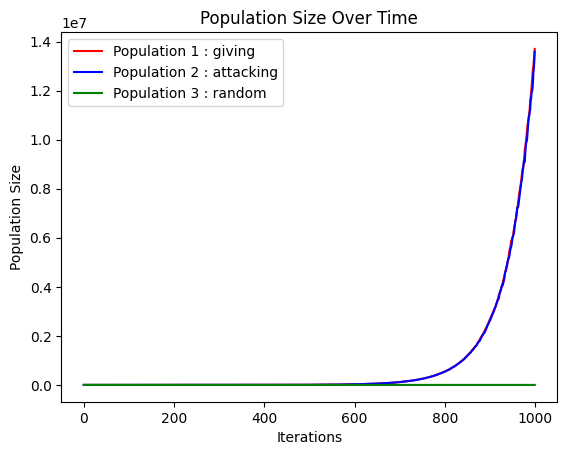

In [ ]:
# if save_dir is None, the images will not be saved

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

# Number of iterations 
iterations = 1000

# Simulation parameters
nb_batches = 100
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                populations=populations, device=device)
simulation.reset()

get_results_imgs(simulation, iterations=iterations, save_dir=SAVE_DIR)